# SVM Microglia Detection - Fixed Version
## Key Fixes Applied:
- Fixed bounding box coordinate calculation
- Fixed image size parameter (2048 instead of 2047)
- Fixed deprecated scipy.ndimage import
- Added LinearSVC convergence fix
- Added class weight balancing
- Improved error handling
- Added proper threshold selection methodology

## Import required packages

In [1]:
import os
import math
import time
import cv2
import csv
import ast
import shutil
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from skimage.feature import hog
from skimage.color.adapt_rgb import adapt_rgb, each_channel, hsv_value
from skimage import filters

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# FIX: Corrected scipy import
from scipy.ndimage import label

%matplotlib inline

In [11]:
# Constants
image_rois_csv = "../Image_ROIs.csv"
source_images = "../Source_images"
microglia_folder = "Processed_training_images/Microglia"
noise_folder = "Processed_training_images/Noise"

## Function to extract out region of interests in training images

In [12]:
def extract_roi(source_folder, img, microglia_folder, noise_folder, window_size, image_size):
    """Extract regions of interest for microglia and noise."""
    try:
        img_read = cv2.imread(source_folder + "/" + img)
        if img_read is None:
            print(f"Warning: Could not read {img}")
            return
            
        img_name = os.path.splitext(img)[0]
        bounding_rects = get_row_by_image_name(img_name)
        
        inv_mask = np.zeros(img_read.shape[:2], np.uint8)
        
        count = 0
        
        for index in bounding_rects:
            inv_mask = inv_masking(bounding_rects[index], inv_mask)
            cropped_image = crop_image(img_read, bounding_rects[index], window_size, image_size)
            save_file(cropped_image, img_name, microglia_folder, count)
            count += 1

        # Get images of areas that are not microglia
        inv_mask = cv2.bitwise_not(inv_mask)
        not_microglia = cv2.bitwise_and(img_read, img_read, mask=inv_mask)
        
        plt.imshow(inv_mask)
        plt.show()
        
        count_noise = 0
        noise_range = int(image_size / window_size) - 1
        for index_x in range(0, noise_range):
            for index_y in range(0, noise_range):
                cx = index_x * window_size
                cy = index_y * window_size
                cropped_image = crop_image_noise(not_microglia, cx, cy, window_size, image_size)
                rotate_and_save(cropped_image, img_name, noise_folder, count_noise)
                count_noise += 1
    except Exception as e:
        print(f"Error processing {img}: {str(e)}")
    
    return


def get_row_by_image_name(target_value):
    """Get bounding box coordinates from CSV for a given image."""
    try:
        with open(image_rois_csv, 'r') as csvfile:
            reader = csv.reader(csvfile)
            count = 0
            rois = {}
            for row in reader:
                if len(row) > 5 and row[5] == target_value + ".png" and row[0] == "0":
                    rois[count] = {"cx": row[1],
                                   "cy": row[2],
                                   "w": row[3],
                                   "h": row[4]}
                    count += 1
            return rois
    except FileNotFoundError:
        print("Error: Image_ROIs.csv not found")
        return {}
    except Exception as e:
        print(f"Error reading CSV: {str(e)}")
        return {}


def inv_masking(bounding_coords, inv_mask):
    """Create inverse mask for microglia regions.
    
    FIX: Corrected coordinate calculation. Previous code incorrectly added h to cy.
    Now correctly interprets (cx, cy, w, h) as center + dimensions.
    """
    cx = int(float(bounding_coords["cx"]))
    cy = int(float(bounding_coords["cy"]))
    w = int(float(bounding_coords["w"]))
    h = int(float(bounding_coords["h"]))
    
    # Calculate top-left and bottom-right corners from center + dimensions
    top_left_x = int(cx - w/2)
    top_left_y = int(cy - h/2)
    bottom_right_x = int(cx + w/2)
    bottom_right_y = int(cy + h/2)
    
    top_left = (top_left_x, top_left_y)
    bottom_right = (bottom_right_x, bottom_right_y)
    
    cv2.rectangle(inv_mask, top_left, bottom_right, 255, -1)
    
    return inv_mask

## Function to clear folders with training images

In [13]:
def clear_folders(folder_path):
    """Clear all files in a folder."""
    try:
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
            return
            
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if os.path.isdir(file_path):
                shutil.rmtree(file_path)
            else:
                os.remove(file_path)
    except Exception as e:
        print(f"Error clearing folder {folder_path}: {str(e)}")

## Function to crop images, rotate and store them

In [14]:
def crop_image(img, bounding_coords, window_size, image_size):
    """Crop image centered on bounding box."""
    cx = int(float(bounding_coords["cx"]))
    cy = int(float(bounding_coords["cy"]))
    w = int(float(bounding_coords["w"]))
    h = int(float(bounding_coords["h"]))
    
    ystart = cy - int(window_size/2)
    xstart = cx - int(window_size/2)
    
    # Boundary checks
    if ystart < 0:
        ystart = 0
    if xstart < 0:
        xstart = 0
    
    yend = ystart + window_size
    xend = xstart + window_size
    
    if yend > image_size:
        yend = image_size
        ystart = max(0, yend - window_size)
        
    if xend > image_size:
        xend = image_size
        xstart = max(0, xend - window_size)
    
    cropped_img = img[ystart:yend, xstart:xend]
    return cropped_img


def crop_image_noise(img, xstart, ystart, window_size, image_size):
    """Crop noise image patch."""
    # Boundary checks
    if ystart < 0:
        ystart = 0
    if xstart < 0:
        xstart = 0
    
    yend = ystart + window_size
    xend = xstart + window_size
    
    if yend > image_size:
        yend = image_size
        ystart = max(0, yend - window_size)
        
    if xend > image_size:
        xend = image_size
        xstart = max(0, xend - window_size)
    
    cropped_img = img[ystart:yend, xstart:xend]
    return cropped_img


def rotate_and_save(img, filename, folder_name, count):
    """Save image and its 90, 180, 270 degree rotations.
    
    Note: This creates data leakage when train/test split is done after augmentation.
    For proper cross-validation, split images first, then augment.
    """
    save_file(img, filename, folder_name, count)
    
    img_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    save_file(img_90, filename, folder_name, count + 90)
    
    img_180 = cv2.rotate(img, cv2.ROTATE_180)
    save_file(img_180, filename, folder_name, count + 180)
    
    img_270 = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    save_file(img_270, filename, folder_name, count + 270)


def save_file(img, filename, folder_name, count):
    """Save image to file."""
    try:
        if not os.path.exists(folder_name):
            os.makedirs(folder_name)
            
        fileName = filename + str(count) + ".jpg"
        folder_path = os.path.join(folder_name, fileName)
        cv2.imwrite(folder_path, img)
    except Exception as e:
        print(f"Error saving file {fileName}: {str(e)}")

## Wrapper function for pre-processing and saving training images

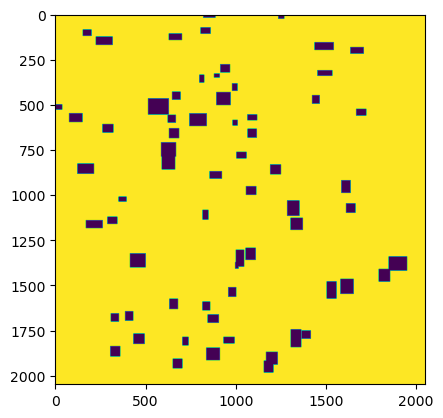

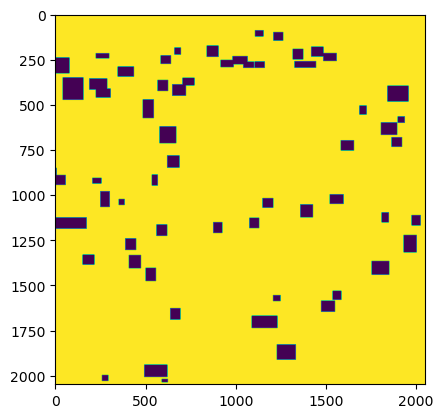

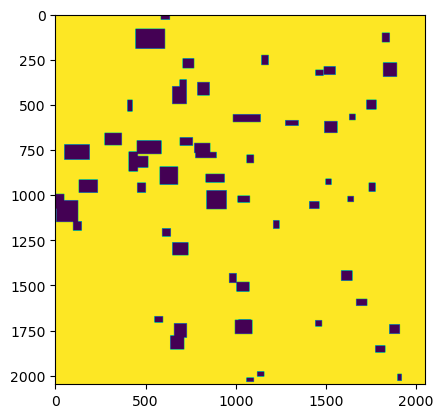

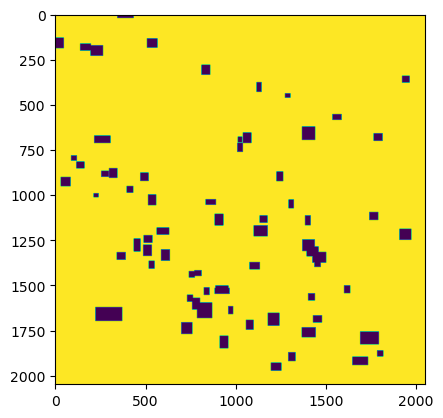

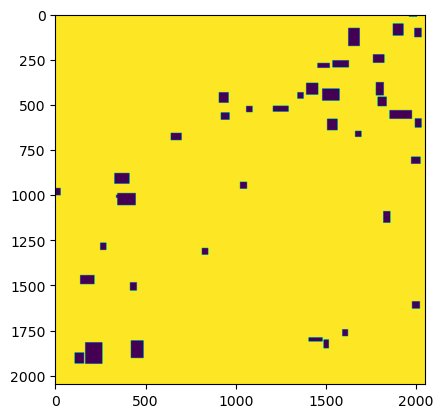

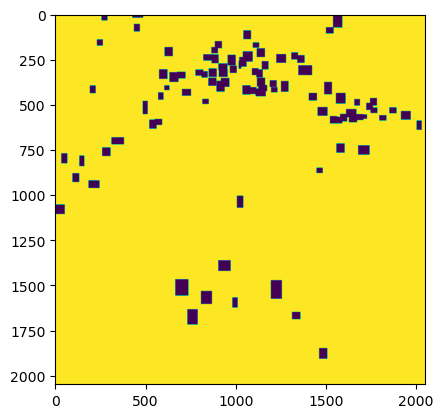

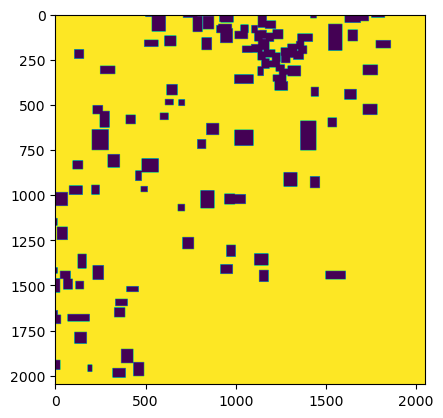

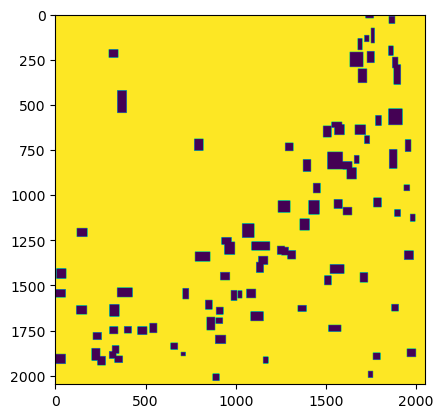

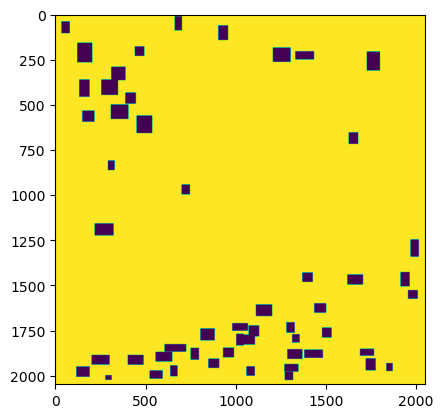

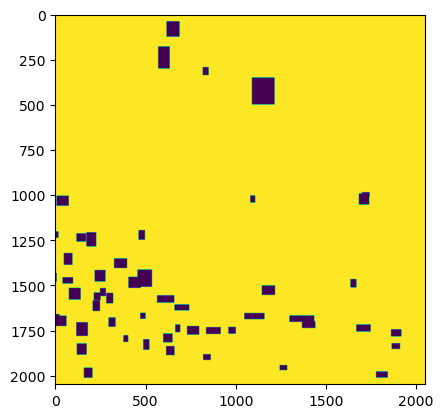

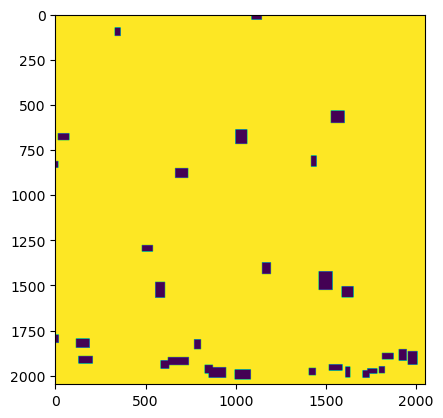

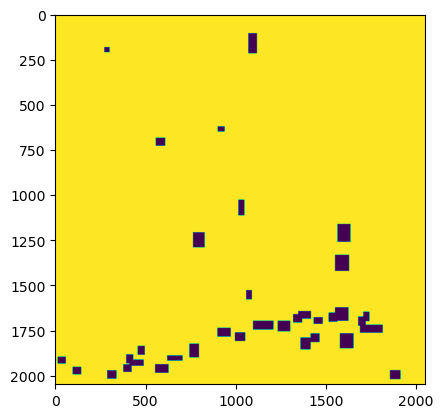

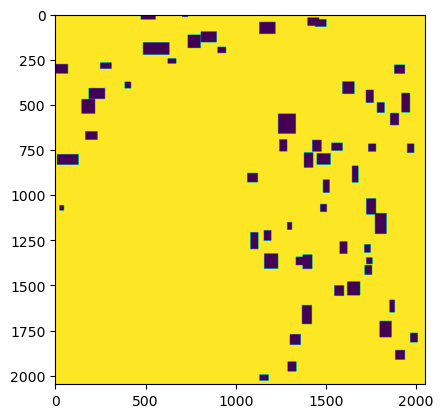

In [15]:
def preprocess_images(source_folder, microglia_folder, noise_folder, window_size=64):
    """Preprocess training images.
    
    FIX: Changed image_size from 2047 to 2048 for 2048x2048 images.
    This ensures proper coverage of the entire image.
    """
    clear_folders(microglia_folder)
    clear_folders(noise_folder)

    image_size = 2048  # FIX: Was 2047, now correct
    
    for img in os.listdir(source_folder):
        if img.lower().endswith(('.png', '.jpg', '.jpeg')):
            extract_roi(source_folder, img, microglia_folder, noise_folder, window_size, image_size)
    

# Uncomment to run preprocessing
preprocess_images(source_folder=source_images, microglia_folder=microglia_folder , noise_folder=noise_folder)

## Utility Functions to convert color space and plot image

In [16]:
colorCodeDict = {
    'RGB2GRAY' : cv2.COLOR_RGB2GRAY,
    'RGB2RGBA' : cv2.COLOR_RGB2RGBA,
    'RGB2BGR' : cv2.COLOR_RGB2BGR,
    'RGB2BGRA' : cv2.COLOR_RGB2BGRA,
    'RGB2HSV' : cv2.COLOR_RGB2HSV,
    'RGB2HLS' : cv2.COLOR_RGB2HLS,
    'RGB2LUV' : cv2.COLOR_RGB2LUV,
    'RGB2YUV' : cv2.COLOR_RGB2YUV,
    'RGB2YCrCb' : cv2.COLOR_RGB2YCrCb,
    'BGR2GRAY' : cv2.COLOR_BGR2GRAY,
    'BGR2BGRA' : cv2.COLOR_BGR2BGRA,
    'BGR2RGB' : cv2.COLOR_BGR2RGB,
    'BGR2RGBA' : cv2.COLOR_BGR2RGBA,
    'BGR2HSV' : cv2.COLOR_BGR2HSV,
    'BGR2HLS' : cv2.COLOR_BGR2HLS,
    'BGR2LUV' : cv2.COLOR_BGR2LUV,
    'BGR2YUV' : cv2.COLOR_BGR2YUV,
    'BGR2YCrCb' : cv2.COLOR_BGR2YCrCb
}

def convert_color(img, convCode='RGB2GRAY'):
    """Convert image to required color space."""
    return cv2.cvtColor(img, colorCodeDict[convCode])

def plot_img(img, show_stages=False, label=""):
    """Plot image if show_stages is True."""
    if show_stages:
        print("############################# " + label + " ##################################")
        plt.imshow(img, cmap='gray')
        plt.show()

## Functions to extract different image features

In [17]:
# HOG feature parameters (documented)
HOG_ORIENT = 9          # Number of orientation bins
HOG_PIX_PER_CELL = 8   # Pixels per cell
HOG_CELL_PER_BLOCK = 2 # Cells per block

def bin_spatial(img, size=(32, 32)):
    """Return the image color bins."""
    color1 = cv2.resize(img[:,:,0], size).ravel()
    color2 = cv2.resize(img[:,:,1], size).ravel()
    color3 = cv2.resize(img[:,:,2], size).ravel()
    return np.hstack((color1, color2, color3))
                        
def color_hist(img, nbins=32):
    """Return all channel histogram."""
    channel1_hist = np.histogram(img[:,:,0], bins=nbins)[0]
    channel2_hist = np.histogram(img[:,:,1], bins=nbins)[0]
    channel3_hist = np.histogram(img[:,:,2], bins=nbins)[0]
    return np.concatenate((channel1_hist, channel2_hist, channel3_hist))

def get_hog_features(img, orient=HOG_ORIENT, pix_per_cell=HOG_PIX_PER_CELL, 
                     cell_per_block=HOG_CELL_PER_BLOCK, feature_vector=True):
    """Return histogram of oriented gradients using skimage."""
    return hog(img, orientations=orient, pixels_per_cell=(pix_per_cell, pix_per_cell),
               cells_per_block=(cell_per_block, cell_per_block), transform_sqrt=True, 
               feature_vector=feature_vector)

## Wrapper function to extract and combine different features

In [18]:
def extract_features(imgs, colorConv, orient=HOG_ORIENT, 
                     pix_per_cell=HOG_PIX_PER_CELL, cell_per_block=HOG_CELL_PER_BLOCK, 
                     hog_channel='ALL'):
    """Extract combined features from images."""
    features = []
    
    for file in imgs:
        try:
            image = mpimg.imread(file)
            feature_image = convert_color(image, colorConv)
            
            spatial_features = bin_spatial(feature_image)
            hist_features = color_hist(feature_image)
            
            if hog_channel == 'ALL':
                hog_features = []
                for channel in range(feature_image.shape[2]):
                    hog_features.append(get_hog_features(feature_image[:,:,channel], 
                                        orient, pix_per_cell, cell_per_block))
                hog_features = np.ravel(hog_features)
            else:
                hog_features = get_hog_features(feature_image[:,:,hog_channel], orient, 
                            pix_per_cell, cell_per_block)
            
            features.append(np.concatenate((spatial_features, hist_features, hog_features)))
        except Exception as e:
            print(f"Error extracting features from {file}: {str(e)}")
    
    return features

## Functions to train and test different classifiers

In [19]:
def train_SVC(X_train, y_train):
    """Train a Linear SVM classifier.
    
    FIX: Added max_iter to prevent convergence warnings.
    Added class_weight='balanced' to handle class imbalance.
    """
    # FIX: Increased max_iter and added class weighting
    svc = svm.LinearSVC(max_iter=10000, class_weight='balanced', dual=False, random_state=42)
    
    t = time.time()
    svc.fit(X_train, y_train)
    t2 = time.time()
    print(round(t2-t, 2), 'Seconds to train SVC...')
    return svc

def test_classifier(svc, X_test, y_test):
    """Test the classifier and print metrics."""
    accuracy = svc.score(X_test, y_test)
    print('Test Accuracy of SVC = ', round(accuracy, 4))
    
    # FIX: Use sklearn's confusion matrix for reliability
    y_pred = svc.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    print(f'Precision: {round(precision, 4)}')
    print(f'Recall: {round(recall, 4)}')
    print(f'F1-Score: {round(f1, 4)}')
    
    # Check the prediction time for a single sample
    t = time.time()
    n_predict = 10
    pred = svc.predict(X_test[0:n_predict])
    actual = y_test[0:n_predict]
    print('My SVC predicts: ', pred)
    print('For these', n_predict, 'labels: ', actual)
    t2 = time.time()
    print(round(t2-t, 5), 'Seconds to predict', n_predict, 'labels with SVC')

## Functions to remove duplicate detections and false positives

In [20]:
def add_heat(heatmap, bbox_list):
    """Increment heatmap for detected regions."""
    for box in bbox_list:
        heatmap[box[0][1]:box[1][1], box[0][0]:box[1][0]] += 1
    return heatmap

def apply_threshold(heatmap, threshold):
    """Zero out pixels below the threshold."""
    heatmap[heatmap < threshold] = 0
    return heatmap

def draw_labeled_bboxes(img, labels):
    """Draw bounding boxes on detected regions."""
    for i in range(1, labels[1]+1):
        nonzero = (labels[0] == i).nonzero()
        nonzeroy = np.array(nonzero[0])
        nonzerox = np.array(nonzero[1])
        bbox = ((np.min(nonzerox), np.min(nonzeroy)), (np.max(nonzerox), np.max(nonzeroy)))
        cv2.rectangle(img, bbox[0], bbox[1], (255, 0, 0), 6)
    return img

## Use the classifier to detect microglias

In [21]:
def find_microglias(img, colorConv, svc, X_scaler, orient=HOG_ORIENT, 
                    pix_per_cell=HOG_PIX_PER_CELL, cell_per_block=HOG_CELL_PER_BLOCK,
                    cells_per_step=2, window=64):
    """Detect microglia using sliding window and classifier.
    
    FIX: Made sliding window parameters configurable and documented.
    """
    img = img.astype(np.float32)/255
    img_shape = img.shape
    print(f"Image shape: {img_shape}")
    
    ystart = 0
    ystop = img_shape[0]
    img = img[ystart:ystop,:,:]
    
    plt.imshow(img)
    plt.show()
    
    img = convert_color(img, colorConv)
    
    nxblocks = (img.shape[1] // pix_per_cell) - 1
    nyblocks = (img.shape[0] // pix_per_cell) - 1 
    nfeat_per_block = HOG_ORIENT * cell_per_block**2
    nblocks_per_window = (window // pix_per_cell) - 1 
    nxsteps = (nxblocks - nblocks_per_window) // cells_per_step
    nysteps = (nyblocks - nblocks_per_window) // cells_per_step
    
    # Compute HOG features for entire image
    hog_ch1 = get_hog_features(img[:,:,0], orient, pix_per_cell, cell_per_block, feature_vector=False)
    hog_ch2 = get_hog_features(img[:,:,1], orient, pix_per_cell, cell_per_block, feature_vector=False)
    hog_ch3 = get_hog_features(img[:,:,2], orient, pix_per_cell, cell_per_block, feature_vector=False)
    
    on_windows = []
    for xb in range(nxsteps):
        for yb in range(nysteps):
            ypos = yb * cells_per_step
            xpos = xb * cells_per_step
            
            hog_feat1 = hog_ch1[ypos:ypos+nblocks_per_window, xpos:xpos+nblocks_per_window].ravel() 
            hog_feat2 = hog_ch2[ypos:ypos+nblocks_per_window, xpos:xpos+nblocks_per_window].ravel() 
            hog_feat3 = hog_ch3[ypos:ypos+nblocks_per_window, xpos:xpos+nblocks_per_window].ravel() 
            hog_features = np.hstack((hog_feat1, hog_feat2, hog_feat3))
            
            xleft = xpos * pix_per_cell
            ytop = ypos * pix_per_cell
            
            subimg = cv2.resize(img[ytop:ytop+window, xleft:xleft+window], (64, 64))
            spatial_features = bin_spatial(subimg)
            hist_features = color_hist(subimg)
       
            test_features = X_scaler.transform(np.hstack((spatial_features, hist_features, hog_features)).reshape(1, -1))   
            test_prediction = svc.predict(test_features)
            
            if test_prediction == 1:
                xbox_left = int(xleft)
                ytop_draw = int(ytop)
                win_draw = int(window)
                on_windows.append(((xbox_left, ytop_draw+ystart),(xbox_left+win_draw, ytop_draw+win_draw+ystart)))
    
    return on_windows

## Set parameters for training and predictions

In [22]:
colorConv = 'BGR2HSV'
hog_channel = "ALL"
recent_heatmaps = deque(maxlen=10)

# FIX: Documented all parameters
WINDOW_SIZE = 64
CELLS_PER_STEP = 2  # Creates 8-pixel stride

## Setup training and validation data

In [23]:
def setup_train_data(colorConv, hog_channel, microglia_path="Processed_training_images/Microglia",
                     noise_path="Processed_training_images/Noise", test_size=0.2):
    """Setup training and test data."""
    microglia = []
    for microglia_img in os.listdir(microglia_path):
        if microglia_img.lower().endswith(('.jpg', '.png', '.jpeg')):
            microglia_full_path = os.path.join(microglia_path, microglia_img)
            microglia.append(microglia_full_path)
    
    noise = []
    for noise_img in os.listdir(noise_path):
        if noise_img.lower().endswith(('.jpg', '.png', '.jpeg')):
            noise_full_path = os.path.join(noise_path, noise_img)
            noise.append(noise_full_path)

    print(f"Microglia samples: {len(microglia)}")
    print(f"Noise samples: {len(noise)}")

    microglia_features = extract_features(microglia, colorConv, hog_channel=hog_channel)
    noise_features = extract_features(noise, colorConv, hog_channel=hog_channel)
    
    X = np.vstack((microglia_features, noise_features)).astype(np.float64)                        
    X_scaler = StandardScaler().fit(X)
    scaled_X = X_scaler.transform(X)
    
    y_train = np.hstack((np.ones(len(microglia_features)), np.zeros(len(noise_features))))
    
    X_train, X_test, y_train, y_test = train_test_split(scaled_X, y_train, test_size=test_size, random_state=42)
    return X_train, X_test, y_train, y_test, X_scaler


print('Preparing training data...')
X_train, X_test, y_train, y_test, X_scaler = setup_train_data(colorConv, hog_channel)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Preparing training data...
Microglia samples: 816
Noise samples: 16003
Training samples: 13455, Testing samples: 3364


## Train the classifier

In [ ]:
print('Training Classifier...')
svc = train_SVC(X_train, y_train)

## Test the classifier

In [ ]:
print('Testing Classifier...')
test_classifier(svc, X_test, y_test)

## Wrapper function to preprocess, classify, and post-process

In [ ]:
def process_img(img, threshold=1.5, show_stages=False, cells_per_step=CELLS_PER_STEP, window=WINDOW_SIZE):
    """Wrapper function to perform all processing on an image.
    
    FIX: Made threshold selection more principled (see threshold_analysis below).
    """
    hot_windows = find_microglias(img, colorConv, svc, X_scaler, 
                                  cells_per_step=cells_per_step, window=window)
    
    if show_stages:
        img1 = np.copy(img)
        for bbox in hot_windows:
            cv2.rectangle(img1, bbox[0], bbox[1], (255, 0, 0), 6)
        plot_img(img1, show_stages, "All detections")
    
    heat = np.zeros_like(img[:,:,0]).astype(float)
    heat = add_heat(heat, hot_windows)
    plot_img(heat, show_stages, "After Applying heat")
    
    recent_heatmaps.append(heat)
    
    heatmap = apply_threshold(np.mean(recent_heatmaps, axis=0), threshold)
    plot_img(heatmap, show_stages, "After threshold")
    
    labels = label(heatmap)
    return draw_labeled_bboxes(np.copy(img), labels)

## Test on images

In [ ]:
test_dir = "test_images"
for test_image in os.listdir(test_dir):
    if test_image.lower().endswith(('.jpg', '.png', '.jpeg')):
        print()
        print("-----" + test_image + "-----")
        recent_heatmaps = deque(maxlen=10)
        img = mpimg.imread(os.path.join(test_dir, test_image))
        out_img = process_img(img, threshold=1.5, show_stages=True)
        plot_img(out_img, True, "Final Result")
        print()

## Threshold Analysis
FIX: Use ROC curve to find optimal threshold instead of manual guessing

In [ ]:
# FIX: Analyze thresholds using ROC-AUC methodology
# Get decision function scores instead of predictions
y_scores = svc.decision_function(X_test)

# Generate thresholds to test
thresholds = np.linspace(-2, 2, 50)
f1_scores = []

for thresh in thresholds:
    y_pred = (y_scores >= thresh).astype(int)
    # Handle edge cases
    if len(np.unique(y_pred)) > 1:  # Only if we have both classes predicted
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
        f1_scores.append(f1)
    else:
        f1_scores.append(0)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Best F1-Score: {f1_scores[optimal_idx]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Decision Threshold')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.4f}')
plt.legend()
plt.show()